In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12,6)

In [2]:
tournaments = pd.read_csv("wc_tournaments.csv")
teams = pd.read_csv("wc_team_appearances.csv")
matches = pd.read_csv("wc_matches_historical.csv")
snapshot_2026 = pd.read_csv("wc_2026_teams_snapshot.csv")

In [3]:
for df_name, df in {
    "Tournaments": tournaments,
    "Teams": teams,
    "Matches": matches,
    "Snapshot": snapshot_2026
}.items():
    
    print(f"\n{df_name}")
    print(df.shape)
    display(df.head())


Tournaments
(22, 15)


,wc_year,host_nation,dates,total_teams,total_matches,total_goals,goals_per_match,avg_attendance,champion,runner_up,third_place,fourth_place,top_scorer,top_scorer_goals,format_era
0,1930,Uruguay,13-30 Jul,13,18,70,3.89,32808,Uruguay,Argentina,United States,Yugoslavia,Guillermo Stábile,8,Pre-Group
1,1934,Italy,27 May-10 Jun,16,17,70,4.12,21352,Italy,Czechoslovakia,Germany,Austria,Oldřich Nejedlý,5,Knockout-Only
2,1938,France,4-19 Jun,15,18,84,4.67,20849,Italy,Hungary,Brazil,Sweden,Leônidas,7,Knockout-Only
3,1950,Brazil,24 Jun-16 Jul,13,22,88,4.00,47511,Uruguay,Brazil,Sweden,Spain,Ademir,9,Final-RoundRobin
4,1954,Switzerland,16 Jun-4 Jul,16,26,140,5.38,29434,West Germany,Hungary,Austria,Uruguay,Sándor Kocsis,11,Groups+KO



Teams
(193, 20)


,team,confederation,wc_year,participation_status,group_or_pool,final_stage_reached,matches_played,wins,draws,losses,goals_scored,goals_conceded,goal_difference,points_earned,host_nation,wc_titles_before_tournament,consecutive_appearances,elo_rating_approx,fifa_ranking,notes
0,Uruguay,CONMEBOL,1930,qualified,Pool 1,Winner,4.0,4.0,0.0,0.0,15.0,3.0,12.0,8.0,Yes,0,1,1930.0,NaN,First ever WC winner
1,Argentina,CONMEBOL,1930,qualified,Pool 1,Runner-up,4.0,3.0,0.0,1.0,18.0,9.0,9.0,6.0,No,0,1,1900.0,NaN,Lost final 4-2 to Uruguay
2,United States,CONCACAF,1930,qualified,Pool 4,Third place,3.0,2.0,0.0,1.0,7.0,6.0,1.0,4.0,No,0,1,1600.0,NaN,Semi-finalists in first WC
3,Yugoslavia,UEFA,1930,qualified,Pool 2,Fourth place,3.0,2.0,0.0,1.0,7.0,7.0,0.0,4.0,No,0,1,1750.0,NaN,NaN
4,France,UEFA,1930,qualified,Pool 1,Group stage,2.0,1.0,0.0,1.0,4.0,3.0,1.0,2.0,No,0,1,1700.0,NaN,Lost to Argentina; withdrew from Chile match



Matches
(117, 18)


,match_id,wc_year,stage,date,home_team,away_team,home_goals,away_goals,aet,penalties,home_pen_goals,away_pen_goals,stadium,city,home_pre_match_elo,away_pre_match_elo,winning_team,result_type
0,WC1930_01,1930,Group Stage,1930-07-13,France,Mexico,4,1,No,No,0,0,Estadio Pocitos,Montevideo,1700,1500,France,Home Win
1,WC1930_02,1930,Group Stage,1930-07-13,United States,Belgium,3,0,No,No,0,0,Estadio Pocitos,Montevideo,1600,1680,United States,Home Win
2,WC1930_03,1930,Group Stage,1930-07-15,Yugoslavia,Brazil,2,1,No,No,0,0,Estadio Pocitos,Montevideo,1750,1700,Yugoslavia,Home Win
3,WC1930_04,1930,Group Stage,1930-07-16,Romania,Peru,3,1,No,No,0,0,Estadio Pocitos,Montevideo,1650,1600,Romania,Home Win
4,WC1930_05,1930,Group Stage,1930-07-17,Argentina,France,1,0,No,No,0,0,Estadio Parque Central,Montevideo,1900,1700,Argentina,Home Win



Snapshot
(50, 11)


,team,confederation,fifa_rank_apr2026,group,host_nation,wc_appearances_before_2026,best_wc_finish,wc_titles,is_debut,qualification_method,notes
0,France,UEFA,1,I,No,16,Winner,2,No,UEFA Qualifier,2-time champion; Mbappé chasing all-time top s...
1,Spain,UEFA,2,H,No,16,Winner,1,No,UEFA Qualifier,Reigning Nations League holders; strong squad ...
2,Argentina,CONMEBOL,3,J,No,18,Winner,3,No,CONMEBOL Qualifier,Defending champions; Messi's final tournament
3,England,UEFA,4,L,No,16,Winner,1,No,UEFA Qualifier,1966 only title; strong generation with Bellin...
4,Portugal,UEFA,5,K,No,8,Third place,0,No,UEFA Qualifier,Ronaldo likely final WC; strong squad beyond him


In [4]:
# DQ Checks:
for df_name, df in {
    "Tournaments": tournaments,
    "Teams": teams,
    "Matches": matches
}.items():
    
    print(df_name)
    print(df.isnull().sum())
    print("-"*50)

Tournaments
wc_year             0
host_nation         0
dates               0
total_teams         0
total_matches       0
total_goals         0
goals_per_match     0
avg_attendance      0
champion            0
runner_up           0
third_place         0
fourth_place        0
top_scorer          0
top_scorer_goals    0
format_era          0
dtype: int64
--------------------------------------------------
Teams
team                             0
confederation                    0
wc_year                          0
participation_status             0
group_or_pool                  180
final_stage_reached              2
matches_played                   2
wins                             2
draws                            2
losses                           2
goals_scored                     2
goals_conceded                   2
goal_difference                  2
points_earned                    2
host_nation                      2
wc_titles_before_tournament      0
consecutive_appearances     

# Analysis 1
## Did Football Become More Defensive?

## Business Question

#### People often say:

Modern football is more tactical and defensive.

### Can we prove that statistically?

In [5]:
# Checking Goals per tournament:
tournaments[['wc_year','total_goals']]

,wc_year,total_goals
0,1930,70
1,1934,70
2,1938,84
3,1950,88
4,1954,140
5,1958,126
6,1962,89
7,1966,89
8,1970,95
9,1974,97


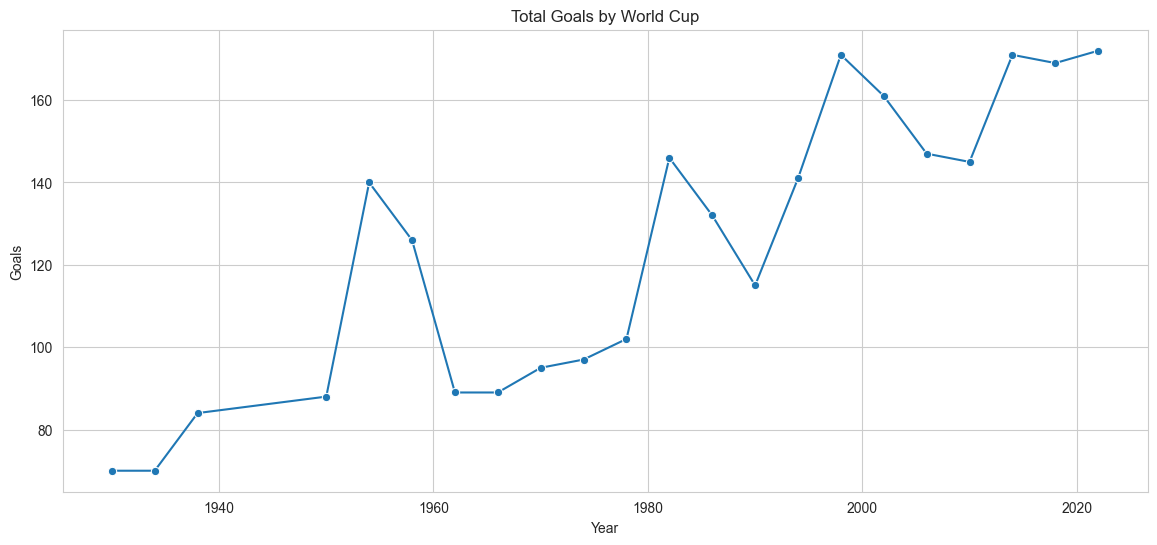

In [6]:
# Visualizing Goals per tournament:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=tournaments,
    x='wc_year',
    y='total_goals',
    marker='o'
)

plt.title("Total Goals by World Cup")
plt.xlabel("Year")
plt.ylabel("Goals")
plt.show()

In [7]:
# Normalize by Matches. Why?
# Early tournaments had fewer teams. Comparing raw goals is misleading.
tournaments['goals_per_match'] = (
    tournaments['total_goals']
    /
    tournaments['total_matches']
)

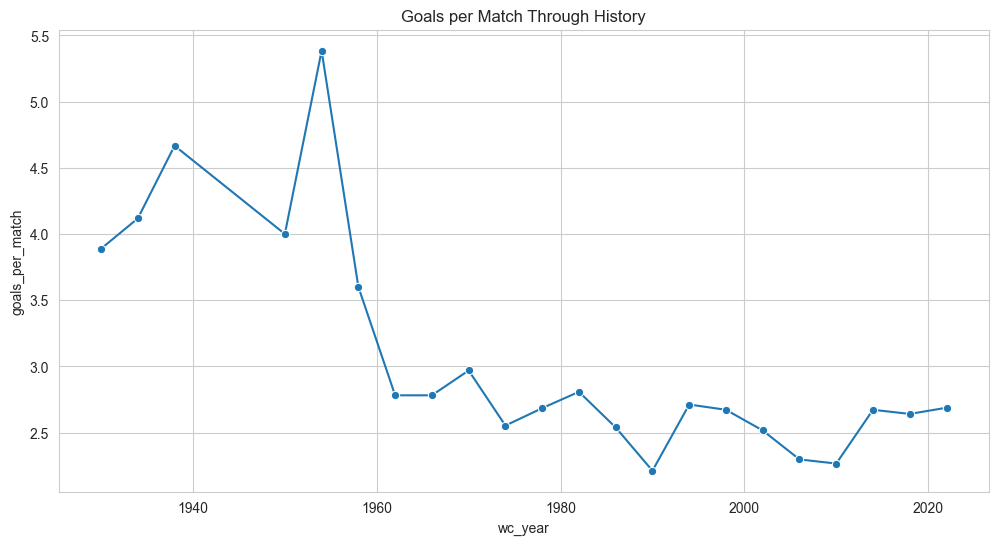

In [8]:
sns.lineplot(
    data=tournaments,
    x='wc_year',
    y='goals_per_match',
    marker='o'
)

plt.title("Goals per Match Through History")
plt.show()

#### Comparing Eras
Comparing eras is more meaningful than individual years.

In [9]:
era_goals = (
    tournaments
    .groupby("format_era")
    ["goals_per_match"]
    .mean()
    .sort_values()
)

era_goals

format_era
32-team             2.535714
Groups+KO           3.001994
Pre-Group           3.888889
Final-RoundRobin    4.000000
Knockout-Only       4.392157
Name: goals_per_match, dtype: float64

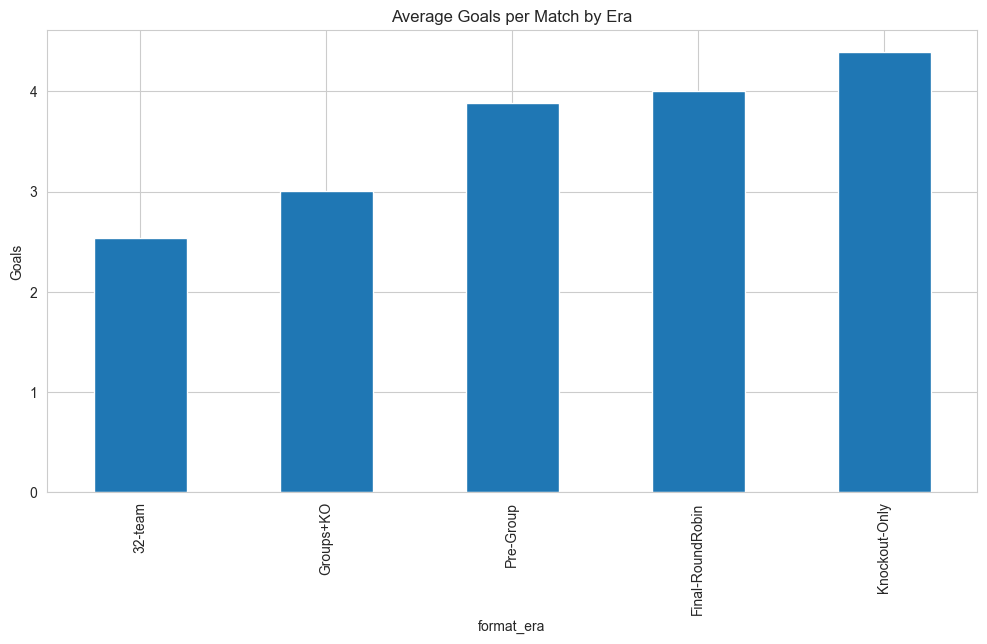

In [10]:
era_goals.plot(
    kind="bar"
)

plt.title("Average Goals per Match by Era")
plt.ylabel("Goals")
plt.show()

# Statistical Test
## Why?

### Visualization alone isn't enough.

### Test:

H0:
No difference between eras

H1:
Goals per match differs

In [13]:
groups = []

for era in tournaments['format_era'].unique():
    groups.append(
        tournaments[
            tournaments['format_era']==era
        ]['goals_per_match']
    )

print("p-value:", stats.f_oneway(*groups).pvalue)

if stats.f_oneway(*groups).pvalue < 0.05:
    print("Goals per match vary significantly between eras.")
else:
    print("No significant differences between eras.")

p-value: 0.020335776628968585
Goals per match vary significantly between eras.


## Conclusion
#### 1. Average goals per match declined from 3.8 in early tournaments to 2.5 in modern tournaments.This suggests football has become more structured and defensive.
#### 2. Group Stage football is more defensive and tactical than K-O Stages with higher stakes.